# Find worst performing classes by model prediction

In [ ]:
from typing import List
from pydantic import BaseModel
import json
from pathlib import Path
#locals
from configs import get_class_list
from video_dataset import get_wlasl_info, get_labels_path, load_data_from_json
from utils import plt_display_grid, load_rgb_frames_from_video
from video_dataset import get_video_path, get_transform
from preprocess import Instance
from stats import (
    AVAIL_SETS,
    AVAIL_SPLITS,
    reverse_preproc_format,
    to_preproc_format,
)
from run_types import AdminInfo, CentreCropConfig, OG_Sampler
from models import get_model
from configs import load_config
from testing import setup_data, test_topk_clsrep, get_res_path
import torch

Set some parameters

In [2]:
verbosity = 1
save_files = False
def printv(*args, level=1, **kwargs):
    if level <= verbosity:
        print(*args, **kwargs)
        
split_idx = 3 #change for different split
split_options: List[AVAIL_SPLITS] = ["asl100", "asl300", "asl1000", "asl2000"]
set_options: List[AVAIL_SETS] = ['train', 'test', 'val']
split_name: AVAIL_SPLITS = split_options[split_idx]
set_idx = 1 #change for different set
set_name: AVAIL_SETS = set_options[set_idx]
classes = get_class_list()
check_name = 'best.pth'
printv(f'Split name: {split_name}')
printv(f'Set name: {set_name}')

Split name: asl2000
Set name: test


In [3]:
admin = AdminInfo.model_validate({
    "model" : "MViTv2_B_32x3",
    "dataset": "WLASL",
    "split": "asl2000",
    "save_path": "runs/asl2000/MViTv2_B_32x3/exp004/checkpoints",
    "exp_no": "004",
    "recover": False,
    "config_path": "configfiles/asl2000/MViTv2_B_32x3/exp004.toml",
    "weight_path": "runs/asl1000/MViTv2_B_32x3/exp001/checkpoints/best.pth"
})
config = load_config(admin)
save_path = Path(admin.save_path)



In [4]:
test_loader, num_classes, _, _ = setup_data(set_name, split_name, config.data)
print(f'Num classed: {num_classes}')
print(f'Num instances: {len(test_loader)}')

Num classed: 2000
Num instances: 2879


In [5]:
model = get_model(admin.model, num_classes, 0.0)
check_path = save_path / check_name
print(f"Loading weights from: {check_path}")
checkpoint = torch.load(check_path)
model.load_state_dict(checkpoint)


Loading weights from: runs/asl2000/MViTv2_B_32x3/exp004/checkpoints/best.pth


/tmp/ipykernel_2322334/2116541114.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(check_path)


<All keys matched successfully>

In [ ]:
print(f"Testing on {set_name} set")
topk_res, cls_report, all_targets, all_preds = test_topk_clsrep(
        model=model,
        test_loader=test_loader,
        verbose=False,
    )

Testing on test set


Testing: 100%|██████████| 2879/2879 [11:18<00:00,  4.24it/s]

top-k average per class acc: 0.47614999999999996, 0.8120666666666666, 0.8781083333333334
top-k per instance acc: 0.5008683570684266, 0.8134769017019798, 0.8763459534560611
Averag Loss: 2.49


In [9]:
res_path = get_res_path(save_path)
print(res_path)

runs/asl2000/MViTv2_B_32x3/exp004/results/best_val_loss.json


In [ ]:
out_dict1 = {
    'test': topk_res.model_dump(),
    'cls_report': cls_report,
}
outp1 = res_path.parent / 'topk_cls_report.json'

# with open(outp1, 'w') as f:
#     json.dump(out_dict1, f, indent=4)


out_dict2 = {
    'all_targets': all_targets,
    'all_preds': all_preds
}
outp2 = res_path.parent / 'all_targets_preds.json'

# with open(outp2, 'w') as f:
#     json.dump(out_dict1, f)

print(f'saved to : {outp1} and {outp2}')    


saved to : runs/asl2000/MViTv2_B_32x3/exp004/results/topk_cls_report.json and runs/asl2000/MViTv2_B_32x3/exp004/results/all_targets_preds.json


In [11]:
print(cls_report.keys())

dict_keys(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', 

In [13]:
print(cls_report['0'].keys())

dict_keys(['precision', 'recall', 'f1-score', 'support'])


In [17]:
print(cls_report['0']['f1-score'])

1.0


In [20]:
metric = 'f1-score'

gloss_metrics = [ 
    (key, item[metric]) for key, item in cls_report.items() if key[0].isdigit()
]

print(gloss_metrics[0])
print(len(gloss_metrics))

('0', 1.0)
2000


In [21]:
sorted_glosses = sorted(
    gloss_metrics,
    key=lambda x: x[1]
)

print(sorted_glosses[0])

('3', 0.0)


In [22]:
bottom_100_label_nums = [
    int(i) for i, _ in sorted_glosses[:100]
]

bottom_100_label_names = [classes[i] for i in bottom_100_label_nums]

In [23]:
cls_idx = bottom_100_label_nums[1] # change for different class
split_name = split_options[split_idx]
set_name = set_options[set_idx]

all_sets = {}
tot = 0
for set_name in set_options:
    set_path_info = get_wlasl_info(split_name, set_name)
    set_path = get_labels_path(set_name, set_path_info['labels'], set_path_info['label_suff'])
    all_sets[set_name] = reverse_preproc_format(
        load_data_from_json(set_path, policy="strict"),
        classes)
    printv(f'Num classes of {set_name}: {len(all_sets[set_name])}', level=2)
    tot += len(all_sets[set_name])



exampler_iterator = iter(all_sets[set_name][cls_idx]['instances'])
idx = 0
tot_samples = len(all_sets[set_name][cls_idx]["instances"])
set_path_info = get_wlasl_info(split_name, set_name)

In [26]:
target_length = 16
frame_size = 224
basic_transform, _, _ = get_transform(
    temporal_aug=[OG_Sampler(target_length=target_length)],
    spatial_aug=[CentreCropConfig(frame_size=frame_size)],
    normalise_to_float=False,
    permute_time_channel=False
)

Example videos for class: "thin"
Instance: 1/4
Next example video path: ../data/WLASL/WLASL2000/57948.mp4


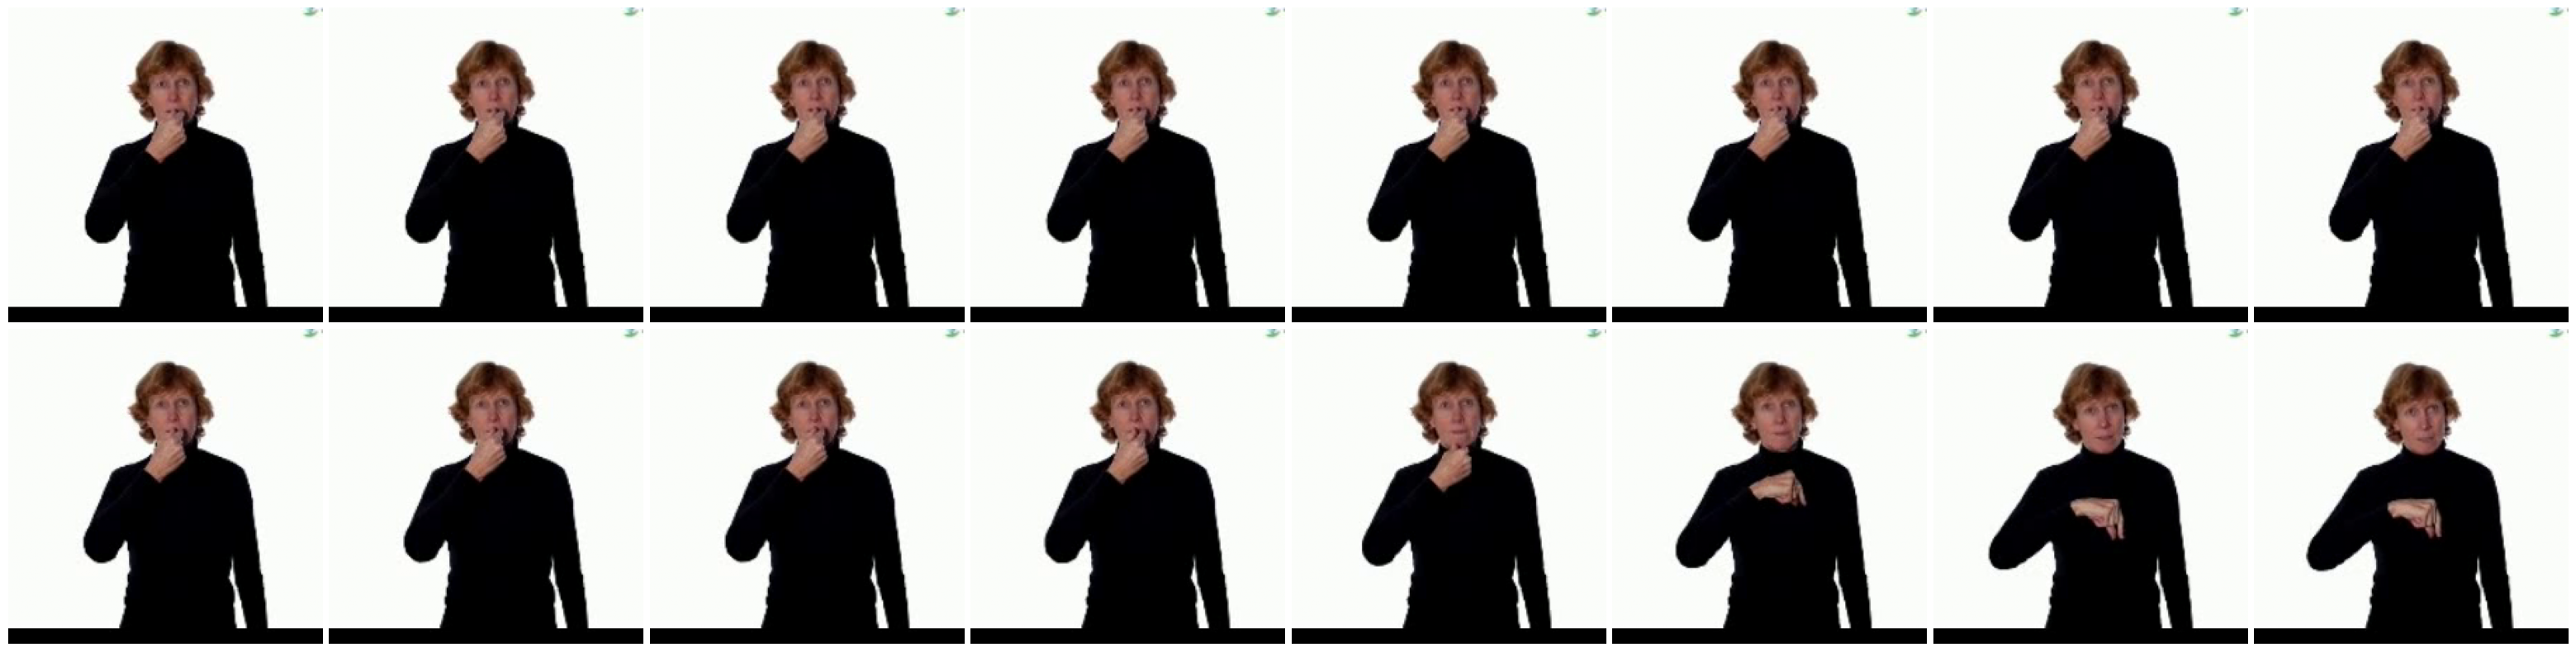

In [27]:
printv(f'Example videos for class: "{classes[cls_idx]}"')
printv(f'Instance: {idx+1}/{tot_samples}')
if idx < tot_samples:
    next_example = Instance.model_validate(next(exampler_iterator))
    ex_path = get_video_path(next_example.video_id, set_path_info['root'])
    
    printv(f'Next example video path: {ex_path}')
    
    plt_display_grid(
        basic_transform(load_rgb_frames_from_video(ex_path, next_example.frame_start, next_example.frame_end)),
        target_length,
    )
else:
    print('No more samples')
    
idx += 1

In [29]:
def _pydantic_default(obj):
    if isinstance(obj, BaseModel):
        return obj.model_dump()

def map_new_labels(instances: List[Instance]) -> List[dict]:
    """Need to remap the labels to be from 0-99 instead of the original label nums
    But want to save the original label nums in the instance info as well for reference
    """
    mapped_instances = []
    for inst in instances:
        original_label_num = inst.label_num
        inst_dict = inst.model_dump()
        inst_dict['original_label_num'] = original_label_num
        inst_dict['label_num'] = bottom_100_label_nums.index(original_label_num)
        mapped_instances.append(inst_dict)
        
    return mapped_instances
        

split_name = 'asl100'
new_split_name = 'asl100_bottom'
new_suffix = f'{metric}_{admin.model}_{admin.split}_{admin.exp_no}.json'
for set_name in set_options:
    bottom_100_subset = to_preproc_format(
        all_sets[set_name],
        criterion=lambda x: x['gloss'] in bottom_100_label_names
    )
    bottom_100_mapped = map_new_labels(bottom_100_subset)
    
    
    
    original_set_path_info = get_wlasl_info(split_name, set_name)
    new_dir = original_set_path_info['labels'].parent / new_split_name 
    # new_dir = Path('preprocessed/labels/asl100_bottom/')
    # assert new_dir.exists() 
    new_path = new_dir / f'{set_name}_{new_suffix}'
    
    new_dir.mkdir(exist_ok=True, parents=True)
    with open(new_path, 'w') as f:
        json.dump(bottom_100_mapped, f, indent=2, default=_pydantic_default)
    printv(f'Saved to: {new_path}')

Saved to: ../data/WLASL/preprocessed/labels/asl100_bottom/train_f1-score_MViTv2_B_32x3_asl2000_004.json
Saved to: ../data/WLASL/preprocessed/labels/asl100_bottom/test_f1-score_MViTv2_B_32x3_asl2000_004.json
Saved to: ../data/WLASL/preprocessed/labels/asl100_bottom/val_f1-score_MViTv2_B_32x3_asl2000_004.json
